In [1]:
!pip install mesa[rec]


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.5/264.5 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.8/454.8 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 43.5 MB/s eta 0:00:00


In [2]:
!pip install seaborn


In [3]:

# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa

In [24]:
import numpy as np

#np.random.seed(10)

# Parametreler
n_strategies = 5
n_scenarios = 3
scenario_probs = [0.25, 0.25, 0.5]  # Toplam 1.0

# Simüle edilmiş getiriler: [strateji][senaryo]
returns = np.random.uniform(-0.05, 0.15, size=(n_strategies, n_scenarios))

# 1. Utility Theory
utility = lambda r: np.mean(r) - 0.5 * np.std(r)
utilities = [utility(returns[i]) for i in range(n_strategies)]
chosen_utility = np.argmax(utilities)

# 2. Expected Utility Theory
expected_utilities = []
for i in range(n_strategies):
    u = [np.log(1 + returns[i][j]) for j in range(n_scenarios)]
    EU = sum(p * u_j for p, u_j in zip(scenario_probs, u))
    expected_utilities.append(EU)
chosen_expected = np.argmax(expected_utilities)

# 3. Bayesian Decision Theory
posterior_probs = np.random.dirichlet(np.ones(n_strategies))
bayesian_utilities = []
for i in range(n_strategies):
    avg_return = np.mean(returns[i])
    U = np.log(1 + avg_return)
    bayesian_utilities.append(posterior_probs[i] * U)
chosen_bayesian = np.argmax(bayesian_utilities)

# 4. Prospect Theory

def value(x, alpha=0.88, lambd=2.25):
    return x**alpha if x >= 0 else -lambd * ((-x)**alpha)

def weight(p, gamma=0.61):
    return (p**gamma) / ((p**gamma + (1 - p)**gamma)**(1 / gamma))

prospect_utilities = []
for i in range(n_strategies):
    v = [value(r) for r in returns[i]]
    w = [weight(p) for p in scenario_probs]
    PT = sum(w_j * v_j for w_j, v_j in zip(w, v))
    prospect_utilities.append(PT)
chosen_prospect = np.argmax(prospect_utilities)

# 5. Bounded Rationality (heuristic): En çok pozitif getiri alan
positive_counts = [np.sum(returns[i] > 0) for i in range(n_strategies)]
chosen_bounded = np.argmax(positive_counts)

# Sonuçlar
print("Getiri Matrisi (strateji x senaryo):\n", np.round(returns, 3))
print("\nSeçilen Stratejiler:")
print("- Utility Theory:", chosen_utility)
print("- Expected Utility Theory:", chosen_expected)
print("- Bayesian Decision Theory:", chosen_bayesian)
print("- Prospect Theory:", chosen_prospect)
print("- Bounded Rationality:", chosen_bounded)


Getiri Matrisi (strateji x senaryo):
 [[ 0.065  0.108  0.062]
 [ 0.125  0.067  0.092]
 [-0.02   0.036  0.089]
 [-0.029  0.038 -0.017]
 [ 0.051  0.114 -0.032]]

Seçilen Stratejiler:
- Utility Theory: 1
- Expected Utility Theory: 1
- Bayesian Decision Theory: 0
- Prospect Theory: 1
- Bounded Rationality: 0


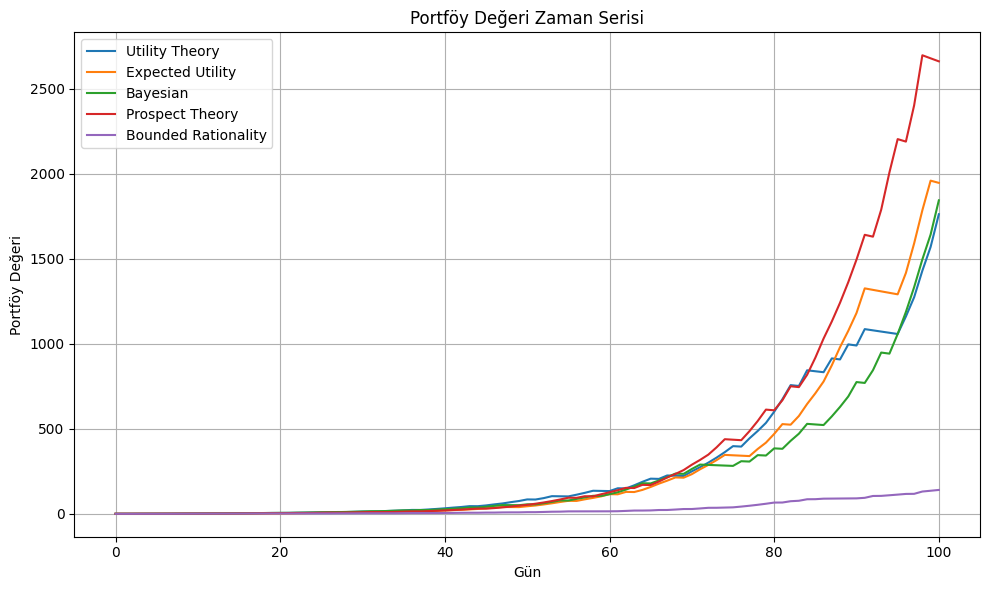

In [29]:
import numpy as np
import matplotlib.pyplot as plt

#np.random.seed(42)

# Parametreler
n_strategies = 5
n_scenarios = 3
scenario_probs = [0.4, 0.35, 0.25]  # Toplam 1.0
n_days = 100  # Simülasyon süresi

# Simüle edilmiş getiriler: [strateji][senaryo]
returns = np.random.uniform(-0.05, 0.15, size=(n_strategies, n_scenarios))

# 1. Utility Theory
utility = lambda r: np.mean(r) - 0.5 * np.std(r)
utilities = [utility(returns[i]) for i in range(n_strategies)]
chosen_utility = np.argmax(utilities)

# 2. Expected Utility Theory
expected_utilities = []
for i in range(n_strategies):
    u = [np.log(1 + returns[i][j]) for j in range(n_scenarios)]
    EU = sum(p * u_j for p, u_j in zip(scenario_probs, u))
    expected_utilities.append(EU)
chosen_expected = np.argmax(expected_utilities)

# 3. Bayesian Decision Theory
posterior_probs = np.random.dirichlet(np.ones(n_strategies))
bayesian_utilities = []
for i in range(n_strategies):
    avg_return = np.mean(returns[i])
    U = np.log(1 + avg_return)
    bayesian_utilities.append(posterior_probs[i] * U)
chosen_bayesian = np.argmax(bayesian_utilities)

# 4. Prospect Theory

def value(x, alpha=0.88, lambd=2.25):
    return x**alpha if x >= 0 else -lambd * ((-x)**alpha)

def weight(p, gamma=0.61):
    return (p**gamma) / ((p**gamma + (1 - p)**gamma)**(1 / gamma))

prospect_utilities = []
for i in range(n_strategies):
    v = [value(r) for r in returns[i]]
    w = [weight(p) for p in scenario_probs]
    PT = sum(w_j * v_j for w_j, v_j in zip(w, v))
    prospect_utilities.append(PT)
chosen_prospect = np.argmax(prospect_utilities)

# 5. Bounded Rationality (heuristic): En çok pozitif getiri alan
positive_counts = [np.sum(returns[i] > 0) for i in range(n_strategies)]
chosen_bounded = np.argmax(positive_counts)

# Seçilen stratejilere göre günlük getiriler üret (her gün senaryo seç ve stratejiye göre getiri al)
def simulate_portfolio(strategy_idx):
    values = [1.0]  # başlangıç portföy değeri
    for _ in range(n_days):
        scenario = np.random.choice(n_scenarios, p=scenario_probs)
        daily_return = returns[strategy_idx][scenario]
        values.append(values[-1] * (1 + daily_return))
    return values

# Portföyleri simüle et
portfolio_utility = simulate_portfolio(chosen_utility)
portfolio_expected = simulate_portfolio(chosen_expected)
portfolio_bayesian = simulate_portfolio(chosen_bayesian)
portfolio_prospect = simulate_portfolio(chosen_prospect)
portfolio_bounded = simulate_portfolio(chosen_bounded)

# Görselleştir
plt.figure(figsize=(10,6))
plt.plot(portfolio_utility, label="Utility Theory")
plt.plot(portfolio_expected, label="Expected Utility")
plt.plot(portfolio_bayesian, label="Bayesian")
plt.plot(portfolio_prospect, label="Prospect Theory")
plt.plot(portfolio_bounded, label="Bounded Rationality")
plt.title("Portföy Değeri Zaman Serisi")
plt.xlabel("Gün")
plt.ylabel("Portföy Değeri")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Performans Karşılaştırması (Ortalama Getiri, Volatilite, Sharpe Oranı):
Utility Theory      : Avg=0.0627, Vol=0.0214, Sharpe=2.93
Expected Utility    : Avg=0.0772, Vol=0.0479, Sharpe=1.61
Bayesian            : Avg=0.0586, Vol=0.0218, Sharpe=2.68
Prospect Theory     : Avg=0.0685, Vol=0.0461, Sharpe=1.49
Bounded Rationality : Avg=0.0683, Vol=0.0497, Sharpe=1.37


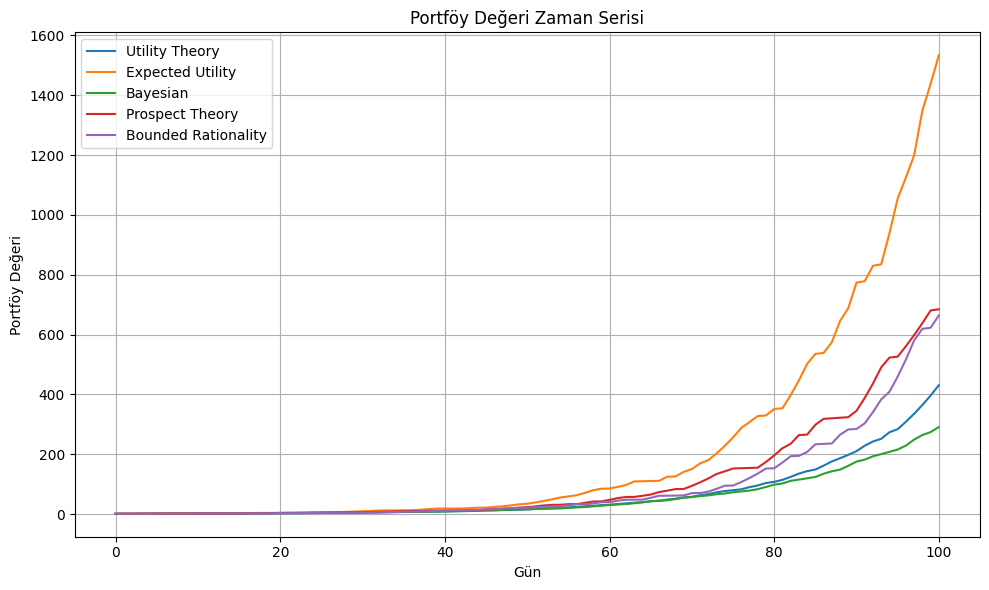

In [35]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(25)

# Parametreler
n_strategies = 5
n_scenarios = 3
scenario_probs = [0.4, 0.35, 0.25]  # Toplam 1.0
n_days = 100  # Simülasyon süresi

# Simüle edilmiş getiriler: [strateji][senaryo]
returns = np.random.uniform(-0.05, 0.15, size=(n_strategies, n_scenarios))

# 1. Utility Theory
utility = lambda r: np.mean(r) - 0.5 * np.std(r)
utilities = [utility(returns[i]) for i in range(n_strategies)]
chosen_utility = np.argmax(utilities)

# 2. Expected Utility Theory
expected_utilities = []
for i in range(n_strategies):
    u = [np.log(1 + returns[i][j]) for j in range(n_scenarios)]
    EU = sum(p * u_j for p, u_j in zip(scenario_probs, u))
    expected_utilities.append(EU)
chosen_expected = np.argmax(expected_utilities)

# 3. Bayesian Decision Theory
posterior_probs = np.random.dirichlet(np.ones(n_strategies))
bayesian_utilities = []
for i in range(n_strategies):
    avg_return = np.mean(returns[i])
    U = np.log(1 + avg_return)
    bayesian_utilities.append(posterior_probs[i] * U)
chosen_bayesian = np.argmax(bayesian_utilities)

# 4. Prospect Theory

def value(x, alpha=0.88, lambd=2.25):
    return x**alpha if x >= 0 else -lambd * ((-x)**alpha)

def weight(p, gamma=0.61):
    return (p**gamma) / ((p**gamma + (1 - p)**gamma)**(1 / gamma))

prospect_utilities = []
for i in range(n_strategies):
    v = [value(r) for r in returns[i]]
    w = [weight(p) for p in scenario_probs]
    PT = sum(w_j * v_j for w_j, v_j in zip(w, v))
    prospect_utilities.append(PT)
chosen_prospect = np.argmax(prospect_utilities)

# 5. Bounded Rationality (heuristic): En çok pozitif getiri alan
positive_counts = [np.sum(returns[i] > 0) for i in range(n_strategies)]
chosen_bounded = np.argmax(positive_counts)

# Seçilen stratejilere göre günlük getiriler üret (her gün senaryo seç ve stratejiye göre getiri al)
def simulate_portfolio(strategy_idx):
    values = [1.0]  # başlangıç portföy değeri
    daily_returns = []
    for _ in range(n_days):
        scenario = np.random.choice(n_scenarios, p=scenario_probs)
        daily_return = returns[strategy_idx][scenario]
        values.append(values[-1] * (1 + daily_return))
        daily_returns.append(daily_return)
    return values, daily_returns

# Portföyleri simüle et
portfolio_utility, r_utility = simulate_portfolio(chosen_utility)
portfolio_expected, r_expected = simulate_portfolio(chosen_expected)
portfolio_bayesian, r_bayesian = simulate_portfolio(chosen_bayesian)
portfolio_prospect, r_prospect = simulate_portfolio(chosen_prospect)
portfolio_bounded, r_bounded = simulate_portfolio(chosen_bounded)

# Performans metrikleri

def performance_metrics(returns):
    avg = np.mean(returns)
    vol = np.std(returns)
    sharpe = avg / vol if vol != 0 else 0
    return avg, vol, sharpe

metrics = {
    "Utility Theory": performance_metrics(r_utility),
    "Expected Utility": performance_metrics(r_expected),
    "Bayesian": performance_metrics(r_bayesian),
    "Prospect Theory": performance_metrics(r_prospect),
    "Bounded Rationality": performance_metrics(r_bounded)
}

# Yazdır
print("Performans Karşılaştırması (Ortalama Getiri, Volatilite, Sharpe Oranı):")
for k, (avg, vol, sharpe) in metrics.items():
    print(f"{k:20s}: Avg={avg:.4f}, Vol={vol:.4f}, Sharpe={sharpe:.2f}")

# Görselleştir
plt.figure(figsize=(10,6))
plt.plot(portfolio_utility, label="Utility Theory")
plt.plot(portfolio_expected, label="Expected Utility")
plt.plot(portfolio_bayesian, label="Bayesian")
plt.plot(portfolio_prospect, label="Prospect Theory")
plt.plot(portfolio_bounded, label="Bounded Rationality")
plt.title("Portföy Değeri Zaman Serisi")
plt.xlabel("Gün")
plt.ylabel("Portföy Değeri")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [49]:
import numpy as np
import matplotlib.pyplot as plt
import random

#np.random.seed(42)
#random.seed(42)

# Parametreler
n_strategies = 5
n_scenarios = 3
scenario_probs = [0.4, 0.35, 0.25]
n_days = 100
n_agents = 10
n_generations = 1

returns = np.random.uniform(-0.05, 0.15, size=(n_strategies, n_scenarios))

def value(x, alpha=0.88, lambd=2.25):
    return x**alpha if x >= 0 else -lambd * ((-x)**alpha)

def weight(p, gamma=0.61):
    return (p**gamma) / ((p**gamma + (1 - p)**gamma)**(1 / gamma))

def simulate_portfolio(strategy_idx):
    value = 1.0
    for _ in range(n_days):
        scenario = np.random.choice(n_scenarios, p=scenario_probs)
        daily_return = returns[strategy_idx][scenario]
        value *= (1 + daily_return)
    return value

# Ajan sınıfı
class Agent:
    def __init__(self, theory):
        self.theory = theory
        self.fitness = 0
        self.strategy = None

    def choose_strategy(self):
        if self.theory == "utility":
            self.strategy = np.argmax([np.mean(r) - 0.5 * np.std(r) for r in returns])
        elif self.theory == "expected":
            self.strategy = np.argmax([
                sum(p * np.log(1 + r_j) for p, r_j in zip(scenario_probs, r))
                for r in returns
            ])
        elif self.theory == "bayesian":
            posteriors = np.random.dirichlet(np.ones(n_strategies))
            self.strategy = np.argmax([posteriors[i] * np.log(1 + np.mean(returns[i])) for i in range(n_strategies)])
        elif self.theory == "prospect":
            self.strategy = np.argmax([
                sum(weight(p) * value(r) for p, r in zip(scenario_probs, strat))
                for strat in returns
            ])
        elif self.theory == "bounded":
            self.strategy = np.argmax([np.sum(r > 0) for r in returns])

    def evaluate(self):
        self.fitness = simulate_portfolio(self.strategy)

# Başlangıç popülasyonu
agent_types = ["utility", "expected", "bayesian", "prospect", "bounded"]
agents = [Agent(random.choice(agent_types)) for _ in range(n_agents)]

# 1 Nesil simülasyonu
for agent in agents:
    agent.choose_strategy()
    agent.evaluate()

# Sonuçları yazdır
print("Ajan Performansları (1. Nesil):")
for i, agent in enumerate(agents):
    print(f"Ajan {i+1}: {agent.theory:10s} | Strateji: {agent.strategy} | Fitness: {agent.fitness:.4f}")


Ajan Performansları (1. Nesil):
Ajan 1: bayesian   | Strateji: 4 | Fitness: 38.8269
Ajan 2: bounded    | Strateji: 0 | Fitness: 241.1705
Ajan 3: bayesian   | Strateji: 3 | Fitness: 6431.8137
Ajan 4: bounded    | Strateji: 0 | Fitness: 259.6938
Ajan 5: expected   | Strateji: 3 | Fitness: 7314.8626
Ajan 6: utility    | Strateji: 3 | Fitness: 9157.5994
Ajan 7: utility    | Strateji: 3 | Fitness: 5173.0144
Ajan 8: expected   | Strateji: 3 | Fitness: 6311.5337
Ajan 9: bayesian   | Strateji: 3 | Fitness: 5597.6593
Ajan 10: utility    | Strateji: 3 | Fitness: 8066.1723


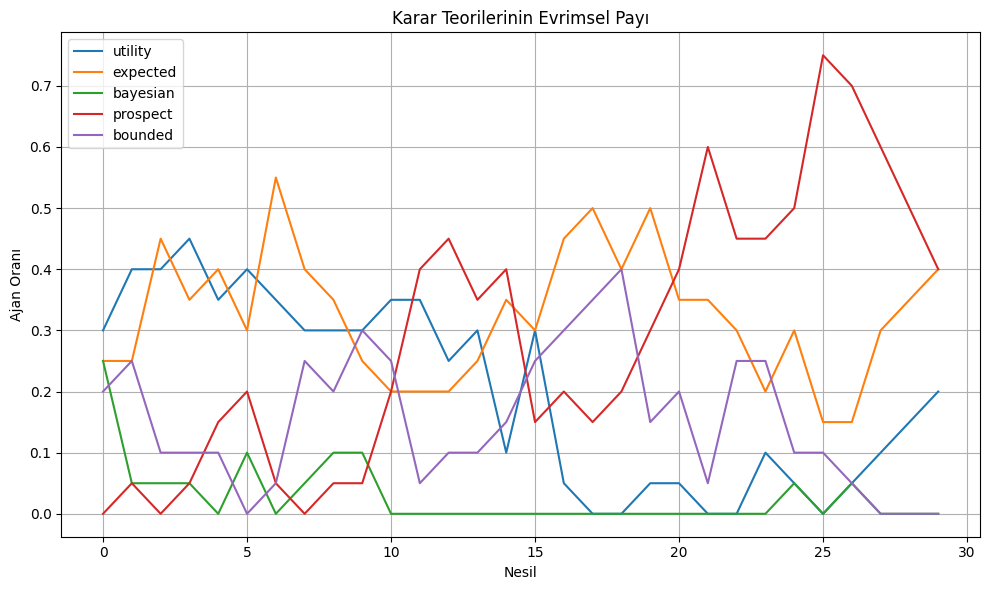

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import Counter

np.random.seed(42)
random.seed(42)

# Parametreler
n_strategies = 5
n_scenarios = 3
scenario_probs = [0.4, 0.35, 0.25]
n_days = 100
n_agents = 20
n_generations = 30
elite_ratio = 0.4
mutation_prob = 0.2

returns = np.random.uniform(-0.05, 0.15, size=(n_strategies, n_scenarios))

def value(x, alpha=0.88, lambd=2.25):
    return x**alpha if x >= 0 else -lambd * ((-x)**alpha)

def weight(p, gamma=0.61):
    return (p**gamma) / ((p**gamma + (1 - p)**gamma)**(1 / gamma))

def simulate_portfolio(strategy_idx):
    value = 1.0
    for _ in range(n_days):
        scenario = np.random.choice(n_scenarios, p=scenario_probs)
        daily_return = returns[strategy_idx][scenario]
        value *= (1 + daily_return)
    return value

# Ajan sınıfı
class Agent:
    def __init__(self, theory):
        self.theory = theory
        self.fitness = 0
        self.strategy = None

    def choose_strategy(self):
        if self.theory == "utility":
            self.strategy = np.argmax([np.mean(r) - 0.5 * np.std(r) for r in returns])
        elif self.theory == "expected":
            self.strategy = np.argmax([
                sum(p * np.log(1 + r_j) for p, r_j in zip(scenario_probs, r))
                for r in returns
            ])
        elif self.theory == "bayesian":
            posteriors = np.random.dirichlet(np.ones(n_strategies))
            self.strategy = np.argmax([posteriors[i] * np.log(1 + np.mean(returns[i])) for i in range(n_strategies)])
        elif self.theory == "prospect":
            self.strategy = np.argmax([
                sum(weight(p) * value(r) for p, r in zip(scenario_probs, strat))
                for strat in returns
            ])
        elif self.theory == "bounded":
            self.strategy = np.argmax([np.sum(r > 0) for r in returns])

    def evaluate(self):
        self.fitness = simulate_portfolio(self.strategy)

# Evrimsel döngü
theories = ["utility", "expected", "bayesian", "prospect", "bounded"]
theory_counts_over_time = []

# İlk nesil
tagents = [Agent(random.choice(theories)) for _ in range(n_agents)]

for generation in range(n_generations):
    for agent in agents:
        agent.choose_strategy()
        agent.evaluate()

    # En iyi ajanları seç (elitizm)
    agents.sort(key=lambda a: a.fitness, reverse=True)
    n_elite = int(elite_ratio * n_agents)
    elites = agents[:n_elite]

    # Yeni nesil oluştur
    new_agents = elites.copy()
    while len(new_agents) < n_agents:
        parent = random.choice(elites)
        if random.random() < mutation_prob:
            new_theory = random.choice([t for t in theories if t != parent.theory])
        else:
            new_theory = parent.theory
        new_agents.append(Agent(new_theory))

    agents = new_agents
    theory_counts = Counter(agent.theory for agent in agents)
    theory_counts_over_time.append(theory_counts)

# Görselleştirme
generations = list(range(n_generations))
theory_labels = theories
theory_series = {theory: [] for theory in theory_labels}

for counts in theory_counts_over_time:
    total = sum(counts.values())
    for theory in theory_labels:
        theory_series[theory].append(counts.get(theory, 0) / total)

plt.figure(figsize=(10, 6))
for theory in theory_labels:
    plt.plot(generations, theory_series[theory], label=theory)
plt.xlabel("Nesil")
plt.ylabel("Ajan Oranı")
plt.title("Karar Teorilerinin Evrimsel Payı")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Karar Teorilerine Göre Performans (Aynı Piyasa):
utility    | Ort. Değer: 133504238.2583 | Vol: 0.0000 | Sharpe: 2986439233863129.50
expected   | Ort. Değer: 133504238.2583 | Vol: 0.0000 | Sharpe: 8959317701589386.00
bayesian   | Ort. Değer: 50716276.8578 | Vol: 64130757.6798 | Sharpe: 0.79
prospect   | Ort. Değer: 133504238.2583 | Vol: 0.0000 | Sharpe: 0.00
bounded    | Ort. Değer: 133504238.2583 | Vol: 0.0000 | Sharpe: 8959317701589386.00


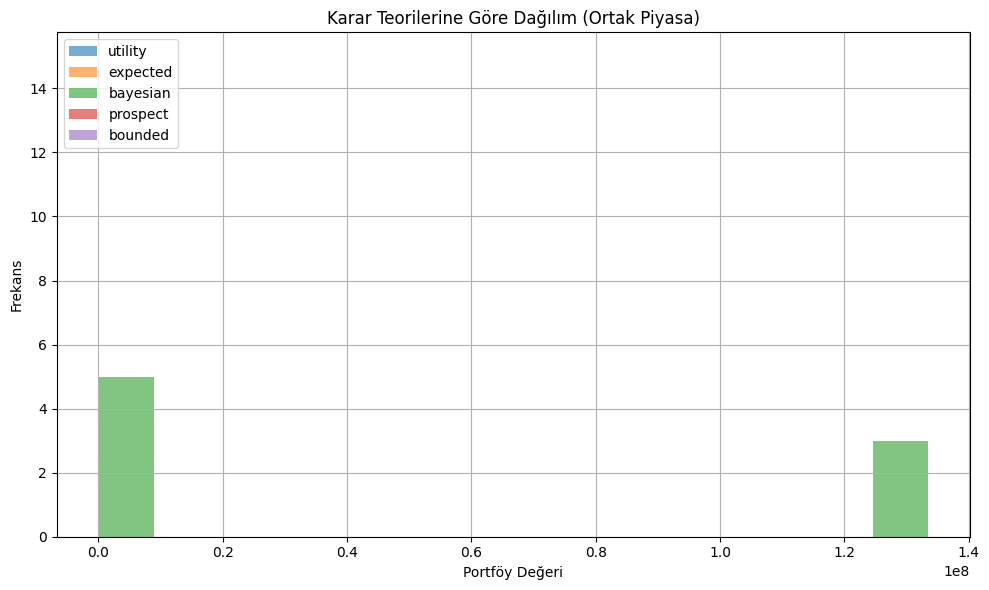

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import defaultdict

np.random.seed(42)
random.seed(42)

# Parametreler
n_strategies = 5
n_scenarios = 3
scenario_probs = [0.4, 0.35, 0.25]
n_days = 250
n_agents = 50
theories = ["utility", "expected", "bayesian", "prospect", "bounded"]

# Strateji getirileri (aynı piyasada herkes için ortak)
returns = np.random.uniform(-0.05, 0.15, size=(n_strategies, n_scenarios))

def value(x, alpha=0.88, lambd=2.25):
    return x**alpha if x >= 0 else -lambd * ((-x)**alpha)

def weight(p, gamma=0.61):
    return (p**gamma) / ((p**gamma + (1 - p)**gamma)**(1 / gamma))

class Agent:
    def __init__(self, theory):
        self.theory = theory
        self.strategy = None
        self.history = []

    def choose_strategy(self):
        if self.theory == "utility":
            self.strategy = np.argmax([np.mean(r) - 0.5 * np.std(r) for r in returns])
        elif self.theory == "expected":
            self.strategy = np.argmax([
                sum(p * np.log(1 + r_j) for p, r_j in zip(scenario_probs, r))
                for r in returns
            ])
        elif self.theory == "bayesian":
            posteriors = np.random.dirichlet(np.ones(n_strategies))
            self.strategy = np.argmax([posteriors[i] * np.log(1 + np.mean(returns[i])) for i in range(n_strategies)])
        elif self.theory == "prospect":
            self.strategy = np.argmax([
                sum(weight(p) * value(r) for p, r in zip(scenario_probs, strat))
                for strat in returns
            ])
        elif self.theory == "bounded":
            self.strategy = np.argmax([np.sum(r > 0) for r in returns])

    def invest(self, scenarios):
        value = 1.0
        for s in scenarios:
            r = returns[self.strategy][s]
            value *= (1 + r)
        self.history.append(value)

# Ortak senaryo akışı (aynı piyasa)
market_scenarios = np.random.choice(n_scenarios, size=n_days, p=scenario_probs)

# Ajanları oluştur
agents = [Agent(theory=random.choice(theories)) for _ in range(n_agents)]

# Simülasyon
for agent in agents:
    agent.choose_strategy()
    agent.invest(market_scenarios)

# Sonuçları topla
results = defaultdict(list)
for agent in agents:
    final_value = agent.history[-1]
    results[agent.theory].append(final_value)

# Ortalama performansları yazdır
print("Karar Teorilerine Göre Performans (Aynı Piyasa):")
for theory in theories:
    data = results[theory]
    avg = np.mean(data)
    std = np.std(data)
    sharpe = (avg - 1) / std if std > 0 else 0
    print(f"{theory:10s} | Ort. Değer: {avg:.4f} | Vol: {std:.4f} | Sharpe: {sharpe:.2f}")

# Görselleştir
plt.figure(figsize=(10, 6))
for theory in theories:
    plt.hist(results[theory], bins=15, alpha=0.6, label=theory)
plt.title("Karar Teorilerine Göre Dağılım (Ortak Piyasa)")
plt.xlabel("Portföy Değeri")
plt.ylabel("Frekans")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


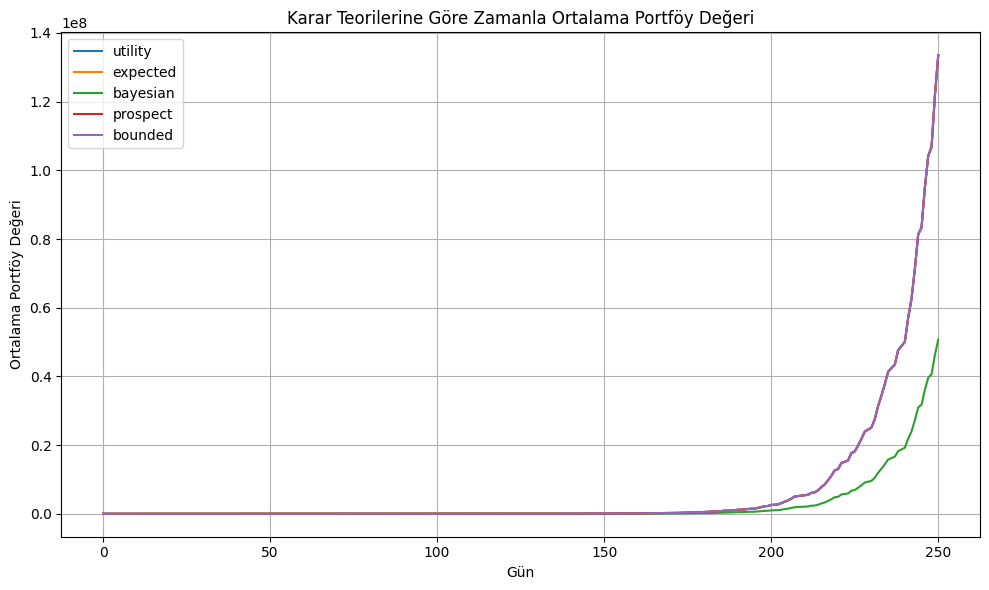

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import defaultdict

np.random.seed(42)
random.seed(42)

# Parametreler
n_strategies = 5
n_scenarios = 3
scenario_probs = [0.4, 0.35, 0.25]
n_days = 250
n_agents = 50
theories = ["utility", "expected", "bayesian", "prospect", "bounded"]

# Strateji getirileri (aynı piyasada herkes için ortak)
returns = np.random.uniform(-0.05, 0.15, size=(n_strategies, n_scenarios))

def value(x, alpha=0.88, lambd=2.25):
    return x**alpha if x >= 0 else -lambd * ((-x)**alpha)

def weight(p, gamma=0.61):
    return (p**gamma) / ((p**gamma + (1 - p)**gamma)**(1 / gamma))

class Agent:
    def __init__(self, theory):
        self.theory = theory
        self.strategy = None
        self.history = []

    def choose_strategy(self):
        if self.theory == "utility":
            self.strategy = np.argmax([np.mean(r) - 0.5 * np.std(r) for r in returns])
        elif self.theory == "expected":
            self.strategy = np.argmax([
                sum(p * np.log(1 + r_j) for p, r_j in zip(scenario_probs, r))
                for r in returns
            ])
        elif self.theory == "bayesian":
            posteriors = np.random.dirichlet(np.ones(n_strategies))
            self.strategy = np.argmax([posteriors[i] * np.log(1 + np.mean(returns[i])) for i in range(n_strategies)])
        elif self.theory == "prospect":
            self.strategy = np.argmax([
                sum(weight(p) * value(r) for p, r in zip(scenario_probs, strat))
                for strat in returns
            ])
        elif self.theory == "bounded":
            self.strategy = np.argmax([np.sum(r > 0) for r in returns])

    def invest_over_time(self, scenarios):
        value = 1.0
        self.history.append(value)
        for s in scenarios:
            r = returns[self.strategy][s]
            value *= (1 + r)
            self.history.append(value)

# Ortak senaryo akışı (aynı piyasa)
market_scenarios = np.random.choice(n_scenarios, size=n_days, p=scenario_probs)

# Ajanları oluştur
agents = [Agent(theory=random.choice(theories)) for _ in range(n_agents)]

# Simülasyon
for agent in agents:
    agent.choose_strategy()
    agent.invest_over_time(market_scenarios)

# Zaman serilerini grupla
time_series = defaultdict(list)
for agent in agents:
    time_series[agent.theory].append(agent.history)

# Ortalama zaman serisini hesapla
avg_series = {}
for theory in theories:
    data = np.array(time_series[theory])
    avg_series[theory] = np.mean(data, axis=0)

# Zaman serisi grafiği
plt.figure(figsize=(10, 6))
for theory in theories:
    plt.plot(avg_series[theory], label=theory)
plt.xlabel("Gün")
plt.ylabel("Ortalama Portföy Değeri")
plt.title("Karar Teorilerine Göre Zamanla Ortalama Portföy Değeri")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


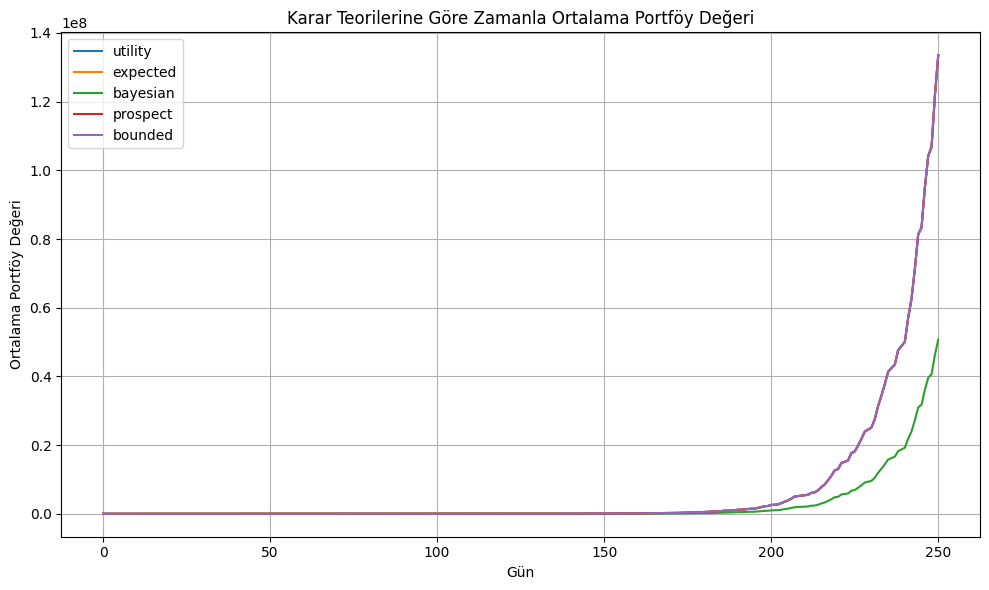


Karar Teorilerine Göre İstatistiksel Özellikler:
utility    | Ort. Değer: 133504238.2583 | Vol: 0.0000 | Sharpe: 2986439233863129.50 | Başarı Oranı: 100.00%
expected   | Ort. Değer: 133504238.2583 | Vol: 0.0000 | Sharpe: 8959317701589386.00 | Başarı Oranı: 100.00%
bayesian   | Ort. Değer: 50716276.8578 | Vol: 64130757.6798 | Sharpe: 0.79 | Başarı Oranı: 100.00%
prospect   | Ort. Değer: 133504238.2583 | Vol: 0.0000 | Sharpe: 0.00 | Başarı Oranı: 100.00%
bounded    | Ort. Değer: 133504238.2583 | Vol: 0.0000 | Sharpe: 8959317701589386.00 | Başarı Oranı: 100.00%


In [53]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import defaultdict

np.random.seed(42)
random.seed(42)

# Parametreler
n_strategies = 5
n_scenarios = 3
scenario_probs = [0.4, 0.35, 0.25]
n_days = 250
n_agents = 50
theories = ["utility", "expected", "bayesian", "prospect", "bounded"]

# Strateji getirileri (aynı piyasada herkes için ortak)
returns = np.random.uniform(-0.05, 0.15, size=(n_strategies, n_scenarios))

def value(x, alpha=0.88, lambd=2.25):
    return x**alpha if x >= 0 else -lambd * ((-x)**alpha)

def weight(p, gamma=0.61):
    return (p**gamma) / ((p**gamma + (1 - p)**gamma)**(1 / gamma))

class Agent:
    def __init__(self, theory):
        self.theory = theory
        self.strategy = None
        self.history = []

    def choose_strategy(self):
        if self.theory == "utility":
            self.strategy = np.argmax([np.mean(r) - 0.5 * np.std(r) for r in returns])
        elif self.theory == "expected":
            self.strategy = np.argmax([
                sum(p * np.log(1 + r_j) for p, r_j in zip(scenario_probs, r))
                for r in returns
            ])
        elif self.theory == "bayesian":
            posteriors = np.random.dirichlet(np.ones(n_strategies))
            self.strategy = np.argmax([posteriors[i] * np.log(1 + np.mean(returns[i])) for i in range(n_strategies)])
        elif self.theory == "prospect":
            self.strategy = np.argmax([
                sum(weight(p) * value(r) for p, r in zip(scenario_probs, strat))
                for strat in returns
            ])
        elif self.theory == "bounded":
            self.strategy = np.argmax([np.sum(r > 0) for r in returns])

    def invest_over_time(self, scenarios):
        value = 1.0
        self.history.append(value)
        for s in scenarios:
            r = returns[self.strategy][s]
            value *= (1 + r)
            self.history.append(value)

# Ortak senaryo akışı (aynı piyasa)
market_scenarios = np.random.choice(n_scenarios, size=n_days, p=scenario_probs)

# Ajanları oluştur
agents = [Agent(theory=random.choice(theories)) for _ in range(n_agents)]

# Simülasyon
for agent in agents:
    agent.choose_strategy()
    agent.invest_over_time(market_scenarios)

# Zaman serilerini grupla
time_series = defaultdict(list)
for agent in agents:
    time_series[agent.theory].append(agent.history)

# Ortalama zaman serisini hesapla
avg_series = {}
for theory in theories:
    data = np.array(time_series[theory])
    avg_series[theory] = np.mean(data, axis=0)

# Zaman serisi grafiği
plt.figure(figsize=(10, 6))
for theory in theories:
    plt.plot(avg_series[theory], label=theory)
plt.xlabel("Gün")
plt.ylabel("Ortalama Portföy Değeri")
plt.title("Karar Teorilerine Göre Zamanla Ortalama Portföy Değeri")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# İstatistiksel analiz
print("\nKarar Teorilerine Göre İstatistiksel Özellikler:")
for theory in theories:
    data = np.array([agent.history for agent in agents if agent.theory == theory])
    final_values = data[:, -1]
    avg = np.mean(final_values)
    std = np.std(final_values)
    sharpe = (avg - 1) / std if std > 0 else 0
    success_rate = np.sum(final_values > 1.0) / len(final_values)
    print(f"{theory:10s} | Ort. Değer: {avg:.4f} | Vol: {std:.4f} | Sharpe: {sharpe:.2f} | Başarı Oranı: {success_rate:.2%}")



--- Evrimsel Turnuva ---
1. Nesil: {'prospect': 14, 'utility': 18, 'expected': 12, 'bayesian': 6}
2. Nesil: {'prospect': 16, 'utility': 20, 'expected': 12, 'bayesian': 2}
3. Nesil: {'prospect': 24, 'utility': 10, 'expected': 16}
4. Nesil: {'prospect': 16, 'utility': 16, 'expected': 18}
5. Nesil: {'prospect': 32, 'expected': 18}
6. Nesil: {'prospect': 50}
7. Nesil: {'prospect': 50}
8. Nesil: {'prospect': 50}
9. Nesil: {'prospect': 50}
10. Nesil: {'prospect': 50}


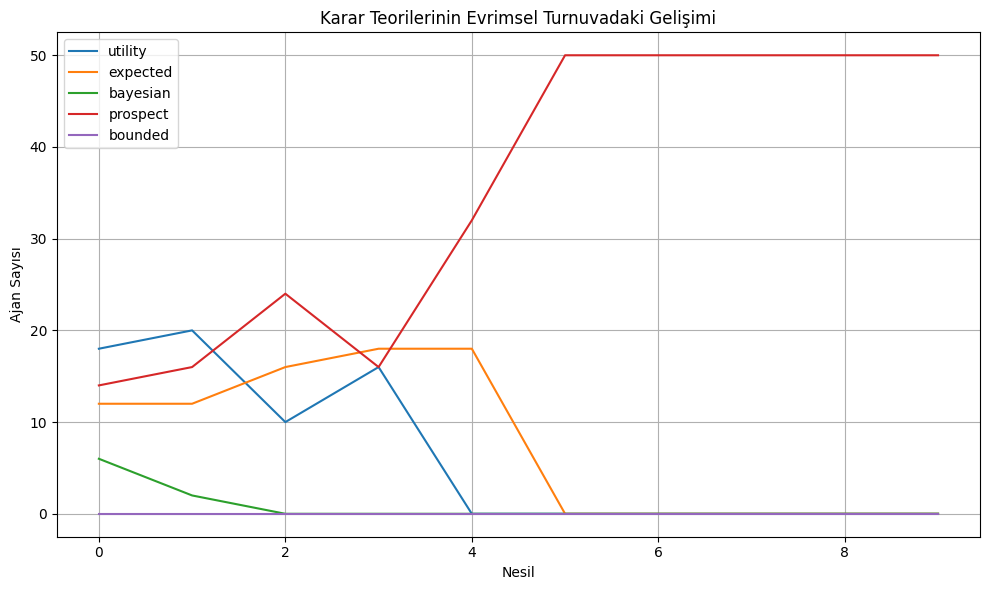

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import defaultdict, Counter

np.random.seed(42)
random.seed(42)

# Parametreler
n_strategies = 5
n_scenarios = 3
scenario_probs = [0.4, 0.35, 0.25]
n_days = 250
n_agents = 50
theories = ["utility", "expected", "bayesian", "prospect", "bounded"]

def value(x, alpha=0.88, lambd=2.25):
    return x**alpha if x >= 0 else -lambd * ((-x)**alpha)

def weight(p, gamma=0.61):
    return (p**gamma) / ((p**gamma + (1 - p)**gamma)**(1 / gamma))

def simulate_market():
    return np.random.choice(n_scenarios, size=n_days, p=scenario_probs)

def generate_returns():
    return np.random.uniform(-0.05, 0.15, size=(n_strategies, n_scenarios))

class Agent:
    def __init__(self, theory):
        self.theory = theory
        self.strategy = None
        self.history = []

    def choose_strategy(self, returns):
        if self.theory == "utility":
            self.strategy = np.argmax([np.mean(r) - 0.5 * np.std(r) for r in returns])
        elif self.theory == "expected":
            self.strategy = np.argmax([
                sum(p * np.log(1 + r_j) for p, r_j in zip(scenario_probs, r))
                for r in returns
            ])
        elif self.theory == "bayesian":
            posteriors = np.random.dirichlet(np.ones(n_strategies))
            self.strategy = np.argmax([posteriors[i] * np.log(1 + np.mean(returns[i])) for i in range(n_strategies)])
        elif self.theory == "prospect":
            self.strategy = np.argmax([
                sum(weight(p) * value(r) for p, r in zip(scenario_probs, strat))
                for strat in returns
            ])
        elif self.theory == "bounded":
            self.strategy = np.argmax([np.sum(r > 0) for r in returns])

    def invest_over_time(self, scenarios, returns):
        value = 1.0
        self.history = [value]
        for s in scenarios:
            r = returns[self.strategy][s]
            value *= (1 + r)
            self.history.append(value)
        return self.history[-1]

def evolutionary_tournament(n_generations=10):
    theory_distribution = random.choices(theories, k=n_agents)
    history = []

    for generation in range(n_generations):
        agents = [Agent(theory) for theory in theory_distribution]
        market_scenarios = simulate_market()
        returns = generate_returns()

        final_values = []
        for agent in agents:
            agent.choose_strategy(returns)
            val = agent.invest_over_time(market_scenarios, returns)
            final_values.append(val)

        sorted_agents = sorted(zip(agents, final_values), key=lambda x: x[1], reverse=True)
        top_agents = sorted_agents[:n_agents // 2]
        next_generation = [agent.theory for agent, _ in top_agents for _ in range(2)]
        theory_distribution = next_generation[:n_agents]

        count = Counter(theory_distribution)
        history.append(dict(count))
        print(f"{generation+1}. Nesil: {dict(count)}")

    return history

# Turnuva başlat
print("\n--- Evrimsel Turnuva ---")
turnuva_sonuclari = evolutionary_tournament(n_generations=10)

# Evrim grafiği
counts_over_time = defaultdict(list)
for generation in turnuva_sonuclari:
    for theory in theories:
        counts_over_time[theory].append(generation.get(theory, 0))

plt.figure(figsize=(10, 6))
for theory in theories:
    plt.plot(counts_over_time[theory], label=theory)
plt.xlabel("Nesil")
plt.ylabel("Ajan Sayısı")
plt.title("Karar Teorilerinin Evrimsel Turnuvadaki Gelişimi")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



--- Karışık Teorili Ajanlarla Turnuva ---
1. Nesil Ort. Ağırlıklar: {'utility': np.float64(0.21776494919791833), 'expected': np.float64(0.1984687644842753), 'bayesian': np.float64(0.2109685378428971), 'prospect': np.float64(0.2067210699937894), 'bounded': np.float64(0.16607667848111976)}
2. Nesil Ort. Ağırlıklar: {'utility': np.float64(0.22839483087434007), 'expected': np.float64(0.17445299395035882), 'bayesian': np.float64(0.20410498204218974), 'prospect': np.float64(0.24099494373575334), 'bounded': np.float64(0.15205224939735815)}
3. Nesil Ort. Ağırlıklar: {'utility': np.float64(0.19224986212264134), 'expected': np.float64(0.20346848881887022), 'bayesian': np.float64(0.2004390283183851), 'prospect': np.float64(0.22639800380904884), 'bounded': np.float64(0.1774446169310545)}
4. Nesil Ort. Ağırlıklar: {'utility': np.float64(0.1710672950725235), 'expected': np.float64(0.2312120340843086), 'bayesian': np.float64(0.2124598016429397), 'prospect': np.float64(0.19957107292112775), 'bounded'

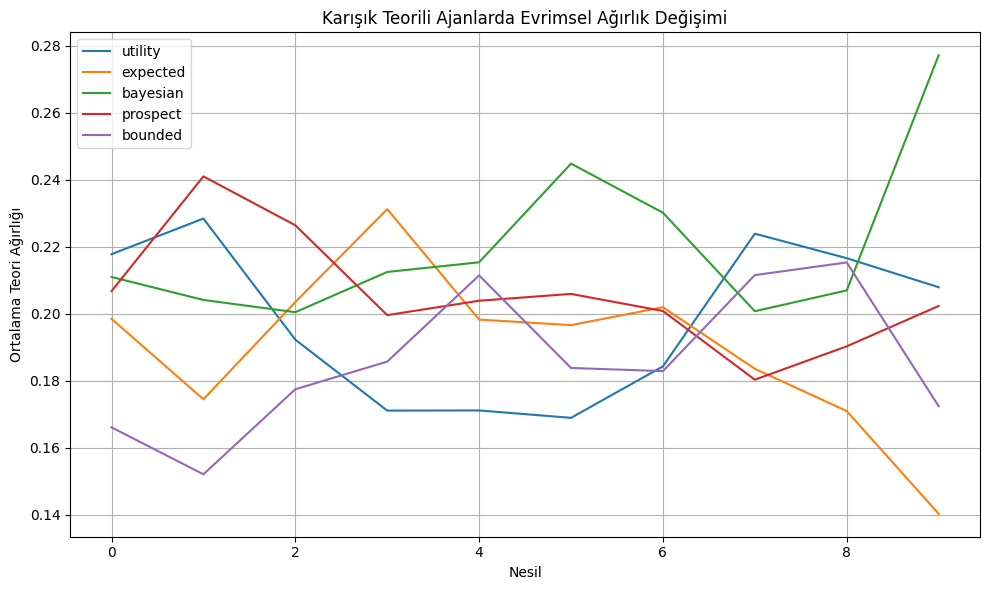

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import defaultdict, Counter

np.random.seed(42)
random.seed(42)

# Parametreler
n_strategies = 5
n_scenarios = 3
scenario_probs = [0.4, 0.35, 0.25]
n_days = 250
n_agents = 50
theories = ["utility", "expected", "bayesian", "prospect", "bounded"]

# Ajanlar karışık teori kombinasyonlarıyla geliyor
class MixedAgent:
    def __init__(self, weights):
        self.weights = weights  # teori: ağırlık
        self.strategy = None
        self.history = []

    def choose_strategy(self, returns):
        scores = np.zeros(len(returns))
        for theory, weight in self.weights.items():
            if theory == "utility":
                scores += weight * np.array([np.mean(r) - 0.5 * np.std(r) for r in returns])
            elif theory == "expected":
                scores += weight * np.array([
                    sum(p * np.log(1 + r_j) for p, r_j in zip(scenario_probs, r))
                    for r in returns
                ])
            elif theory == "bayesian":
                posteriors = np.random.dirichlet(np.ones(n_strategies))
                scores += weight * np.array([posteriors[i] * np.log(1 + np.mean(returns[i])) for i in range(n_strategies)])
            elif theory == "prospect":
                scores += weight * np.array([
                    sum(weight_fn(p) * value_fn(r) for p, r in zip(scenario_probs, strat))
                    for strat in returns
                ])
            elif theory == "bounded":
                scores += weight * np.array([np.sum(r > 0) for r in returns])
        self.strategy = int(np.argmax(scores))

    def invest_over_time(self, scenarios, returns):
        value = 1.0
        self.history = [value]
        for s in scenarios:
            r = returns[self.strategy][s]
            value *= (1 + r)
            self.history.append(value)
        return self.history[-1]

def value_fn(x, alpha=0.88, lambd=2.25):
    return x**alpha if x >= 0 else -lambd * ((-x)**alpha)

def weight_fn(p, gamma=0.61):
    return (p**gamma) / ((p**gamma + (1 - p)**gamma)**(1 / gamma))

def generate_returns():
    return np.random.uniform(-0.05, 0.15, size=(n_strategies, n_scenarios))

def simulate_market():
    return np.random.choice(n_scenarios, size=n_days, p=scenario_probs)

def create_mixed_population(n):
    agents = []
    for _ in range(n):
        weights = np.random.dirichlet(np.ones(len(theories)))
        weight_dict = {theory: weights[i] for i, theory in enumerate(theories)}
        agents.append(MixedAgent(weight_dict))
    return agents

def tournament_with_mixed_agents(n_generations=10):
    agents = create_mixed_population(n_agents)
    history = []

    for generation in range(n_generations):
        market_scenarios = simulate_market()
        returns = generate_returns()
        final_values = []

        for agent in agents:
            agent.choose_strategy(returns)
            val = agent.invest_over_time(market_scenarios, returns)
            final_values.append(val)

        sorted_agents = sorted(zip(agents, final_values), key=lambda x: x[1], reverse=True)
        top_agents = sorted_agents[:n_agents // 2]

        agents = []
        for agent, _ in top_agents:
            for _ in range(2):
                child_weights = np.random.dirichlet([agent.weights[t] * 10 + 1 for t in theories])
                weight_dict = {theory: child_weights[i] for i, theory in enumerate(theories)}
                agents.append(MixedAgent(weight_dict))

        avg_weights = defaultdict(float)
        for agent in agents:
            for t in theories:
                avg_weights[t] += agent.weights[t] / n_agents
        history.append(dict(avg_weights))
        print(f"{generation+1}. Nesil Ort. Ağırlıklar: {dict(avg_weights)}")

    return history

# Simülasyonu çalıştır
print("\n--- Karışık Teorili Ajanlarla Turnuva ---")
karisik_sonuclar = tournament_with_mixed_agents(n_generations=10)

# Zaman içinde ortalama ağırlık grafiği
plt.figure(figsize=(10, 6))
for t in theories:
    plt.plot([h.get(t, 0) for h in karisik_sonuclar], label=t)
plt.xlabel("Nesil")
plt.ylabel("Ortalama Teori Ağırlığı")
plt.title("Karışık Teorili Ajanlarda Evrimsel Ağırlık Değişimi")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
